# Estudo Orientado II — RQ2: Autonomia, Desperdício e Retrabalho (Reprodutibilidade)

**Copiloto ou Piloto? Explorando a Autonomia da IA Generativa na Resolução de Issues**

Reproduz, de forma linear e auto-contida, os achados da **RQ2**:
*Em que proporção agentes de IA contribuem de forma autônoma, e qual o desperdício de ações e o retrabalho humano para integrar esse código?*

**Diferença-chave para a RQ1:** aqui o corpus é **inteiramente de PRs agênticos**. A
classificação humano/IA/bot ocorre **no nível de commit, dentro da branch do PR**
(não entre PRs). As métricas seguem as Eqs. 5 e 6 da metodologia:

- **Retrabalho Humano** = |S_pr_humano ∩ S_main|  (Eq. 5)
- **Desperdício de Ações da IA** = |S_pr_ia \ S_merge|  (Eq. 6)

**Pipeline:**
1. Setup e download
2. Visão geral e contabilidade de exclusões
3. Caracterização dos excluídos (squash / erros)
4. Composição de commits por natureza
5. Métricas da RQ2 (com estatística robusta)
6. Investigação de outliers
7. Comparação entre ferramentas (Devin / Copilot / Claude Code)
8. Visualização

> **Aviso metodológico:** as métricas de ações têm assimetria extrema. Usa-se **mediana**,
> nunca média, e medianas condicionadas aos valores > 0.

## 1. Setup e Download

Os dados da RQ2 estão hospedados publicamente. São dois arquivos:
- `autonomy_waste_rework.csv` — saída do pipeline (uma linha por PR agêntico).
- `autonomy_waste_rework_20260614_003811.log` — log de execução (referência de funil).

In [ ]:
!pip install -q pandas numpy scipy matplotlib seaborn

In [ ]:
!wget -q http://ygor.ml/uff/eo2/results/rq2/autonomy_waste_rework.csv -O autonomy_waste_rework.csv
!wget -q http://ygor.ml/uff/eo2/results/rq2/autonomy_waste_rework_20260619_201458.log -O rq2_pipeline.log
print("Downloads concluídos.")

Downloads concluídos.


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import kruskal, mannwhitneyu

pd.set_option("display.width", 200)
pd.set_option("display.max_columns", 30)

FERRAMENTAS = ["Copilot", "Devin", "Claude_Code"]
print("Ambiente pronto.")

Ambiente pronto.


## 2. Visão Geral e Contabilidade de Exclusões

O CSV tem uma linha por PR agêntico processado. Nem todas são analisáveis: **squash/ff merges**
não permitem separar IA de humano commit a commit, e há **erros de cálculo**. A análise
principal usa apenas os PRs válidos (merge real de dois pais, sem erro).

In [ ]:
df = pd.read_csv("autonomy_waste_rework.csv")
print(f"Total de linhas (PRs processados): {len(df):,}")
print(f"Colunas: {list(df.columns)}")
df.head()

Total de linhas (PRs processados): 45,209
Colunas: ['pr_id', 'repo_id', 'repo_full_name', 'agent', 'merge_sha', 'ancestor_sha', 'main_before_sha', 'pr_head_sha', 'is_squash_merge', 'has_internal_merge', 'internal_merge_sha', 'smain_actions', 'smerge_actions', 'spr_ia_actions', 'spr_humano_actions', 'spr_bot_actions', 'human_rework', 'ia_waste', 'ia_accepted_actions', 'overlap_ia_humano', 'number_commits', 'number_commits_ia', 'number_commits_humano', 'number_commits_bot', 'error_message']


,pr_id,repo_id,repo_full_name,agent,merge_sha,ancestor_sha,main_before_sha,pr_head_sha,is_squash_merge,has_internal_merge,internal_merge_sha,smain_actions,smerge_actions,spr_ia_actions,spr_humano_actions,spr_bot_actions,human_rework,ia_waste,ia_accepted_actions,overlap_ia_humano,number_commits,number_commits_ia,number_commits_humano,number_commits_bot,error_message
0,3142996073,978362165,0xcpu/diremon,Devin,62bff1a519125641f510bbc7a547fbbba0cb5c8b,NaN,69ca24ce337d7b8517f7ad85b34b374e259c0ae5,62bff1a519125641f510bbc7a547fbbba0cb5c8b,1,0,NaN,0,0,0,0,0,0,0,0,0,0,0,0,0,squash/ff merge — classificação commit a commi...
1,3273149656,1005828366,0x-Professor/0x-Professor,Copilot,0b133e958b23bcfb09396fd1dd4fbe505829b729,NaN,bf01c02d45c639e9efe753e7812687089fb088b0,0b133e958b23bcfb09396fd1dd4fbe505829b729,1,0,NaN,0,0,0,0,0,0,0,0,0,0,0,0,0,squash/ff merge — classificação commit a commi...
2,3266935465,1023923380,01U2/FolderScanner,Copilot,803d167f0ec1ff088d9fb0640b71e95cd49c90b2,7ecc8fcadaaaa66d5ad0f883bf86109b8498a79e,7ecc8fcadaaaa66d5ad0f883bf86109b8498a79e,0f6a57c25e0ecac0bcef5eb4ed9d787db08321f1,0,1,0f6a57c25e0ecac0bcef5eb4ed9d787db08321f1,0,0,0,0,0,0,0,0,0,4,0,0,0,merge interno detectado: 0f6a57c25e0ecac0bcef5...
3,3056517726,976640839,0x2me/ai-agent-smith,Devin,e4df9e42c7976fec32481a3e6532eb6f2b296d79,3457b28cd69403403ae53fe434e3527c840a0dee,3457b28cd69403403ae53fe434e3527c840a0dee,140ee614cd7d3a61ea7e57394d343e35678f9ef2,0,0,NaN,0,412,412,0,0,0,0,412,0,2,2,0,0,NaN
4,3219735581,1011142278,0GiS0/mcp-sampling,Copilot,8c0dd03ac6dddde649e61319fcaf6bad3c7701e1,f31dbb0b60c74bbbb6174d1cc1d6c977a331af8d,f31dbb0b60c74bbbb6174d1cc1d6c977a331af8d,201f703f1e49814c71539a977a133d3dc2d48c73,0,0,NaN,0,2,60,0,0,0,58,2,0,3,3,0,0,NaN


In [ ]:
df.repo_id.unique().shape[0]

10790

In [ ]:
df.pr_id.unique().shape[0]

45209

In [ ]:
# Contabilidade: válidos vs excluídos
squash      = df[df.is_squash_merge == 1]
erros_reais = df[(df.is_squash_merge == 0) & (df.error_message.notna())]
valid       = df[(df.is_squash_merge == 0) & (df.error_message.isna())].copy()

print("=== CONTABILIDADE ===")
print(f"  Squash/ff merges ....... {len(squash):>7,} ({len(squash)/len(df)*100:.1f}%)")
print(f"  Erros de cálculo ....... {len(erros_reais):>7,} ({len(erros_reais)/len(df)*100:.1f}%)")
print(f"  VÁLIDOS ................ {len(valid):>7,} ({len(valid)/len(df)*100:.1f}%)")
assert len(squash) + len(erros_reais) + len(valid) == len(df)
print(f"\nRepositórios (válidos): {valid.repo_id.nunique():,}")
print(f"Ferramentas (válidos): {valid.agent.value_counts().to_dict()}")

=== CONTABILIDADE ===
  Squash/ff merges .......  11,409 (25.2%)
  Erros de cálculo .......   3,877 (8.6%)
  VÁLIDOS ................  29,923 (66.2%)

Repositórios (válidos): 7,859
Ferramentas (válidos): {'Copilot': 16822, 'Devin': 11703, 'Claude_Code': 1398}


## 3. Caracterização dos Excluídos

Detalhamento dos PRs que não entraram na análise, para transparência e reprodutibilidade.

In [ ]:
# Categorização dos motivos de exclusão
def categoria_erro(m):
    if pd.isna(m): return "OK"
    s = str(m).lower()
    if "squash" in s or "ff merge" in s: return "squash/ff"
    if "interno" in s: return "merge_interno"
    if "codec" in s: return "encoding"
    if "não tem pais" in s or "sem pais" in s: return "sem_pais"
    if "encontrado" in s: return "sha_nao_encontrado"
    return "outro"

df["motivo"] = df.error_message.apply(categoria_erro)
excluidos = df[(df.is_squash_merge == 1) | (df.error_message.notna())]

print("=== Motivos de exclusão ===")
print(excluidos["motivo"].value_counts().to_string())

print("\n=== Exclusões por ferramenta ===")
tab = excluidos.groupby("agent").size()
total_ag = df.groupby("agent").size()
for ag in FERRAMENTAS:
    print(f"  {ag:12s}: {tab.get(ag,0):>6,} excluídos de {total_ag.get(ag,0):>6,} "
          f"({tab.get(ag,0)/total_ag.get(ag,1)*100:.1f}%)")

=== Motivos de exclusão ===
motivo
squash/ff             11409
merge_interno          2494
sha_nao_encontrado     1305
encoding                 74
sem_pais                  4

=== Exclusões por ferramenta ===
  Copilot     :  8,208 excluídos de 25,030 (32.8%)
  Devin       :  5,403 excluídos de 17,106 (31.6%)
  Claude_Code :  1,675 excluídos de  3,073 (54.5%)


## 4. Composição de Commits por Natureza

Dentro de cada PR agêntico, quantos commits são de IA, humanos ou bots? Esta é a base
para qualquer discussão sobre autonomia (a ser formalmente definida).

In [ ]:
comp = pd.DataFrame({
    "Commits IA":     valid.number_commits_ia,
    "Commits Humano": valid.number_commits_humano,
    "Commits Bot":    valid.number_commits_bot,
}).agg(["mean", "median", lambda s: (s > 0).mean() * 100]).T
comp.columns = ["Média", "Mediana", "% PRs com >0"]
print(f"=== Composição de commits por natureza ({len(valid):,} PRs válidos) ===")
print(comp.round(2).to_string())

so_ia = ((valid.number_commits_humano == 0) & (valid.number_commits_bot == 0)).mean() * 100
com_humano = (valid.number_commits_humano > 0).mean() * 100
print(f"\nPRs com APENAS commits de IA: {so_ia:.1f}%")
print(f"PRs com pelo menos 1 commit humano: {com_humano:.1f}%")

=== Composição de commits por natureza (29,923 PRs válidos) ===
                Média  Mediana  % PRs com >0
Commits IA       2.77      2.0         98.59
Commits Humano   0.25      0.0          8.84
Commits Bot      0.00      0.0          0.19

PRs com APENAS commits de IA: 91.0%
PRs com pelo menos 1 commit humano: 8.8%


## 4.5. Reconciliação com o funil PRISMA do paper

A contabilidade desta seção segue exatamente o funil PRISMA (Figura `fig:prisma-rq2`).
Cada categoria abaixo corresponde a uma das exclusões reportadas no diagrama.

> **Estrutura do funil** (números do paper):
> - Etapa s5 (com `merge_sha` conhecido): **45.607** PRs
> - Etapa s6 (processados / clone bem-sucedido): **45.209** PRs — exclusão: **398** falhas de clone
> - Etapa s7 (corpus final analisável): **29.923** PRs em **7.859** repositórios
> - Exclusões s6 → s7: **11.409** squash/ff + **2.494** merge interno + **1.383** outros erros

In [ ]:
# Reconciliação com o funil PRISMA do paper
print("=== Reconciliação com PRISMA RQ2 ===\n")

# Etapa s6: total no CSV (processados)
total_csv = len(df)
print(f"s6 (Processados): {total_csv:,}  [PRISMA: 45.209]  {'OK' if total_csv==45209 else 'DIVERGÊNCIA'}")

# Etapa s7: corpus final
print(f"s7 (Corpus final analisável): {len(valid):,} PRs / {valid.repo_id.nunique():,} repos  "
      f"[PRISMA: 29.923 / 7.859]  {'OK' if len(valid)==29923 and valid.repo_id.nunique()==7859 else 'DIVERGÊNCIA'}")

# Exclusões s6 → s7
n_squash = int((df.is_squash_merge==1).sum())
n_mi     = int(df.error_message.fillna("").str.contains("interno").sum())
n_outros = int((df.error_message.notna() & ~df.error_message.fillna("").str.contains("interno")).sum()) - n_squash
print(f"\nExclusões s6 → s7:")
print(f"  Squash/ff: {n_squash:,}  [PRISMA: 11.409]  {'OK' if n_squash==11409 else 'DIVERGÊNCIA'}")
print(f"  Merge interno: {n_mi:,}  [PRISMA: 2.494]  {'OK' if n_mi==2494 else 'DIVERGÊNCIA'}")
print(f"  Outros erros: {n_outros:,}  [PRISMA: 1.383]  {'OK' if n_outros==1383 else 'DIVERGÊNCIA'}")

assert len(valid) == 29923, "Corpus final divergente!"
assert valid.repo_id.nunique() == 7859, "Repositórios divergente!"
print("\n✓ Todos os números fecham com o PRISMA do paper")

=== Reconciliação com PRISMA RQ2 ===

s6 (Processados): 45,209  [PRISMA: 45.209]  OK
s7 (Corpus final analisável): 29,923 PRs / 7,859 repos  [PRISMA: 29.923 / 7.859]  OK

Exclusões s6 → s7:
  Squash/ff: 11,409  [PRISMA: 11.409]  OK
  Merge interno: 2,494  [PRISMA: 2.494]  OK
  Outros erros: 1,383  [PRISMA: 1.383]  OK

✓ Todos os números fecham com o PRISMA do paper


## 5. Métricas da RQ2

As duas métricas formais (Eqs. 5 e 6) e as medidas de ações por natureza. Dada a assimetria
extrema, reportamos **proporção de PRs com valor > 0** e **medianas condicionadas a > 0**,
em vez de médias.

In [ ]:
def perfil_robusto(serie):
    pos = serie[serie > 0]
    return pd.Series({
        "% PRs > 0":   (serie > 0).mean() * 100,
        "Mediana(>0)": pos.median() if len(pos) else 0,
        "P90(>0)":     pos.quantile(.90) if len(pos) else 0,
        "P99(>0)":     pos.quantile(.99) if len(pos) else 0,
        "Máximo":      serie.max(),
    })

metricas = ["ia_waste", "human_rework", "spr_humano_actions",
            "spr_ia_actions", "smain_actions", "smerge_actions"]
perfil = pd.DataFrame({m: perfil_robusto(valid[m]) for m in metricas}).T
print("=== Perfil robusto das métricas (válidos) ===")
print(perfil.round(1).to_string())

=== Perfil robusto das métricas (válidos) ===
                    % PRs > 0  Mediana(>0)  P90(>0)  P99(>0)     Máximo
ia_waste                 30.4         26.0    398.0  12611.5  5869488.0
human_rework              8.3         48.0    988.1   7923.4   829459.0
spr_humano_actions        8.6         66.5   1193.7  11538.6   832009.0
spr_ia_actions           92.5        144.0   1667.0  17940.0  5877933.0
smain_actions            16.2        139.0   2020.5  21265.1  1424094.0
smerge_actions           94.4        173.0   1939.0  17224.6  3224931.0


### Interpretação das duas métricas formais

- **`ia_waste` (Eq. 6)** — desperdício de ações da IA que não chegaram ao merge: $|S_{\text{pr\_IA}} \setminus S_{\text{merge}}|$.
- **`human_rework` (Eq. 5)** — retrabalho humano: contribuição humana absorvida na integração: $|S_{\text{pr\_Humano}} \cap S_{\text{merge}}|$.

A definição de retrabalho humano foi **atualizada**: ela mede agora a parcela das ações de
*commits* humanos da branch que sobrevive ao merge — independente do avanço paralelo da
*main*. A formulação original ($S_{\text{pr\_Humano}} \cap S_{\text{main}}$) foi descartada
por ser estruturalmente rara no contexto agêntico: o conjunto $S_{\text{main}}$ só é não-vazio
em ~16% dos PRs, e a métrica saía $>0$ em apenas 0,25% dos casos por construção.

A nova definição reflete o sentido mais direto de *retrabalho*: contribuição humana
incorporada ao resultado final. O limite superior teórico é a parcela de PRs com ações
humanas na branch ($S_{\text{pr\_Humano}} \neq \emptyset$) — em torno de 8,6%.

In [ ]:
# Magnitude e cobertura do retrabalho humano (nova definição)
print("=== Retrabalho humano: presença e cobertura ===")
c_commits = (valid.number_commits_humano > 0).mean() * 100
c_acoes   = (valid.spr_humano_actions > 0).mean() * 100
c_rework  = (valid.human_rework > 0).mean() * 100
print(f"  PRs com commit humano na branch ........... {c_commits:.2f}%  ({int((valid.number_commits_humano>0).sum())} PRs)")
print(f"  PRs com ações humanas (linhas) na branch .. {c_acoes:.2f}%   ({int((valid.spr_humano_actions>0).sum())} PRs)  [limite superior]")
print(f"  PRs com human_rework > 0 .................. {c_rework:.2f}%   ({int((valid.human_rework>0).sum())} PRs)")
print()
print(f"Diferença entre limite superior e observado: {c_acoes - c_rework:.2f} pp")
print("Interpretação: quando há intervenção humana detectável na branch (ações),")
print("a contribuição humana quase sempre sobrevive ao merge — ou seja, o retrabalho")
print("humano captura praticamente toda intervenção humana, não apenas casos raros.")

print()
print("Nota histórica: a definição anterior (Spr_humano ∩ S_main) era estruturalmente")
print(f"limitada por |S_main| > 0, que ocorre em apenas {(valid.smain_actions>0).mean()*100:.1f}% dos PRs do corpus.")
print("Por isso a métrica antiga saía > 0 em apenas ~0,25% dos casos — limitação superada")
print("pela definição atual.")

=== Retrabalho humano: presença e cobertura ===
  PRs com commit humano na branch ........... 8.84%  (2646 PRs)
  PRs com ações humanas (linhas) na branch .. 8.56%   (2562 PRs)  [limite superior]
  PRs com human_rework > 0 .................. 8.29%   (2480 PRs)

Diferença entre limite superior e observado: 0.27 pp
Interpretação: quando há intervenção humana detectável na branch (ações),
a contribuição humana quase sempre sobrevive ao merge — ou seja, o retrabalho
humano captura praticamente toda intervenção humana, não apenas casos raros.

Nota histórica: a definição anterior (Spr_humano ∩ S_main) era estruturalmente
limitada por |S_main| > 0, que ocorre em apenas 16.2% dos PRs do corpus.
Por isso a métrica antiga saía > 0 em apenas ~0,25% dos casos — limitação superada
pela definição atual.


## 5.5. Sobreposição de Autoria IA + Humano

A coluna `overlap_ia_humano = max(0, |S_{pr\_IA} ∩ S_{merge}| + |S_{pr\_Humano} ∩ S_{merge}| - |S_{merge}|)`
quantifica quando uma mesma ação aparece tanto em commits da IA quanto em commits humanos da branch
(reaplicação após conflito, *cherry-pick*, mesma alteração feita por ambas as naturezas).

Sob teoria de conjuntos, esperaria-se `ia_accepted + human_rework ≤ smerge`. Quando essa soma
excede `smerge`, o excedente é atribuído a essa sobreposição.

In [ ]:
# Sobreposição IA + humano nas ações do merge
n_overlap = int((valid.overlap_ia_humano > 0).sum())
pct = n_overlap / len(valid) * 100
print(f"=== overlap_ia_humano ===")
print(f"  PRs com overlap > 0: {n_overlap:,} ({pct:.2f}%)")
print(f"  PRs com overlap == 0: {len(valid)-n_overlap:,}")

nz = valid[valid.overlap_ia_humano > 0].overlap_ia_humano
if len(nz) > 0:
    print(f"\nDistribuição entre os com overlap > 0:")
    print(f"  Mediana: {nz.median():.0f}")
    print(f"  Q1: {nz.quantile(.25):.0f}  Q3: {nz.quantile(.75):.0f}")
    print(f"  P90: {nz.quantile(.90):.0f}  Máximo: {nz.max():.0f}")

# Caracterização: o overlap só ocorre em PRs com IA E humano na branch?
print(f"\nCom IA E humano simultaneamente na branch: "
      f"{int(((valid.spr_ia_actions>0)&(valid.spr_humano_actions>0)).sum()):,} PRs")
print("(o overlap > 0 só faz sentido nesse subconjunto)")

=== overlap_ia_humano ===
  PRs com overlap > 0: 941 (3.14%)
  PRs com overlap == 0: 28,982

Distribuição entre os com overlap > 0:
  Mediana: 6
  Q1: 2  Q3: 17
  P90: 47  Máximo: 842

Com IA E humano simultaneamente na branch: 2,149 PRs
(o overlap > 0 só faz sentido nesse subconjunto)


## 6. Investigação de Outliers de Desperdício

As médias de `ia_waste` são distorcidas por valores extremos. Inspeciona-se os maiores
para verificar se são artefatos (geração massiva de código em projetos de teste/demo).

In [ ]:
top = valid.nlargest(10, "ia_waste")[
    ["repo_full_name", "agent", "ia_waste", "spr_ia_actions",
     "smerge_actions", "number_commits_ia"]]
print("=== TOP 10 ia_waste ===")
print(top.to_string(index=False))

print(f"\nPRs com ia_waste > 100.000: {(valid.ia_waste > 100000).sum()}")
print(f"PRs com ia_waste entre 1 e 10.000: {((valid.ia_waste>0)&(valid.ia_waste<=10000)).sum()}")
print("\nObservação: os extremos são repositórios de teste/demo (nomes como '..._from_devin',")
print("'devin', 'project-forward') onde o agente gerou aplicações inteiras — volume de geração,")
print("não desperdício de raciocínio. Daí o uso de medianas robustas.")

=== TOP 10 ia_waste ===
                      repo_full_name   agent  ia_waste  spr_ia_actions  smerge_actions  number_commits_ia
HiroyasuHigashida/sns_app_from_devin   Devin   5869488         5877933            8445                  1
                       bparanj/devin   Devin   2754975         2766366           11391                  3
                r3e-network/r3e-faas   Devin   2207457         2213698            6241                  2
              njisaf/project-forward   Devin   2137877         2142181            4364                 12
                 jhacksman/arxiv2025   Devin   1566868         1567208         1538130                116
DomC21/neural-network-trading-system   Devin   1460808         1460809               1                  2
               amitrjn/manaable-test   Devin   1394250         1401118            6868                  3
                  ambicuity/trackCTA Copilot   1173385         1198326           24941                  4
               vmillet

## 7. Comparação entre Ferramentas

Devin, Copilot e Claude Code diferem em composição de commits e desperdício. Como as
métricas violam normalidade, usa-se um protocolo não paramétrico em duas etapas:
**Kruskal-Wallis** (omnibus, com $\\varepsilon^2$) seguido de **Mann-Whitney** par-a-par
com correção de **Holm** — apropriada aqui, pois as três comparações confrontam grupos
distintos de PRs (uma família legítima de comparações múltiplas, diferente da análise de
sensibilidade ao $k$ na RQ1). O tamanho de efeito par-a-par é dado por **Cliff's $\\delta$**.

> **Definição operacional adotada:** "% só IA" = PRs em que `number_commits_humano == 0`
> **E** `number_commits_bot == 0`. Captura PRs cujos *commits* da branch são exclusivamente
> da IA agêntica, sem intervenção humana nem de automações (bots de CI, dependabot, etc.).

> **Leitura dos resultados:** a significância estatística decorre do tamanho do corpus
> ($n \\approx 30$ mil); os tamanhos de efeito (Cliff's $\\delta$, $\\varepsilon^2$) indicam
> que o desperdício **não** separa as ferramentas de forma praticamente relevante.

In [ ]:
# Caracterização por ferramenta
linhas = []
for ag in FERRAMENTAS:
    s = valid[valid.agent == ag]
    pos = s[s.ia_waste > 0].ia_waste
    linhas.append({
        "Ferramenta": ag, "n": len(s),
        "% só IA": ((s.number_commits_humano==0)&(s.number_commits_bot==0)).mean()*100,
        "Commits humanos (méd)": s.number_commits_humano.mean(),
        "% c/ desperdício": (s.ia_waste > 0).mean()*100,
        "Mediana desperdício(>0)": pos.median() if len(pos) else 0,
    })
tab_ferramentas = pd.DataFrame(linhas).round(2)
print("=== Caracterização por ferramenta ===")
print(tab_ferramentas.to_string(index=False))

=== Caracterização por ferramenta ===
 Ferramenta     n  % só IA  Commits humanos (méd)  % c/ desperdício  Mediana desperdício(>0)
    Copilot 16822    91.48                   0.21             30.89                     25.0
      Devin 11703    94.26                   0.12             28.67                     24.0
Claude_Code  1398    57.58                   1.74             38.56                     59.0


In [ ]:
# ==========================
# Testes estatísticos sobre o desperdício de ações (ia_waste) entre ferramentas
# Reproduz a Tabela tab:rq2_testes do artigo
# ==========================
from scipy.stats import rankdata

# --- Kruskal-Wallis (omnibus) ---
grupos = [valid[valid.agent == ag].ia_waste.values for ag in FERRAMENTAS]
H, p_kw = kruskal(*grupos)
n, k = len(valid), len(FERRAMENTAS)
epsilon2 = (H - k + 1) / (n - k)   # tamanho de efeito global
print(f"Kruskal-Wallis (ia_waste): H = {H:.2f}, p = {p_kw:.2e}, epsilon² = {epsilon2:.4f}")

# --- Cliff's delta (tamanho de efeito par-a-par) ---
def cliffs_delta(a, b):
    """Cliff's delta via relação com a estatística U de Mann-Whitney.
    delta = 2*U/(n1*n2) - 1, com U computado por ranks (eficiente em O(n log n))."""
    a = np.asarray(a); b = np.asarray(b)
    n1, n2 = len(a), len(b)
    ranks = rankdata(np.concatenate([a, b]))
    r1 = ranks[:n1].sum()
    U1 = r1 - n1 * (n1 + 1) / 2
    return 2 * U1 / (n1 * n2) - 1

def magnitude_cliff(d):
    ad = abs(d)
    if ad < 0.15:  return "desprezível"
    if ad < 0.33:  return "pequeno"
    if ad < 0.47:  return "médio"
    return "grande"

# --- Holm para os p-valores par-a-par ---
def holm(pvals):
    p = np.asarray(pvals, float); m = len(p); ordem = np.argsort(p)
    adj = np.empty(m); run = 0.0
    for i, idx in enumerate(ordem):
        run = max(run, (m - i) * p[idx]); adj[idx] = min(run, 1.0)
    return adj

# --- Mann-Whitney par-a-par + Holm + Cliff's delta ---
pares = [("Copilot", "Devin"), ("Copilot", "Claude_Code"), ("Devin", "Claude_Code")]
pvals, deltas = [], []
for a, b in pares:
    ga = valid[valid.agent == a].ia_waste.values
    gb = valid[valid.agent == b].ia_waste.values
    pvals.append(mannwhitneyu(ga, gb, alternative="two-sided").pvalue)
    deltas.append(cliffs_delta(ga, gb))
holm_p = holm(pvals)

# --- Tabela consolidada (espelha tab:rq2_testes do artigo) ---
tab_testes = pd.DataFrame({
    "Par": [f"{a} vs {b}" for a, b in pares],
    "p (Mann-Whitney)": [f"{p:.2e}" for p in pvals],
    "p (Holm)": [f"{ph:.2e}" for ph in holm_p],
    "Cliff's δ": [round(d, 3) for d in deltas],
    "Magnitude": [magnitude_cliff(d) for d in deltas],
})
print("\n=== Post-hoc: Mann-Whitney par-a-par (ia_waste) ===")
print(tab_testes.to_string(index=False))

print(f"\nResumo: efeito global desprezível (ε²={epsilon2:.3f}); todos os Cliff's δ "
      f"na faixa desprezível (|δ| ≤ {max(abs(d) for d in deltas):.2f}).")
print("Significância decorre do tamanho do corpus (n = {:,}), não de magnitude prática.".format(n))

Kruskal-Wallis (ia_waste): H = 92.15, p = 9.78e-21, epsilon² = 0.0030

=== Post-hoc: Mann-Whitney par-a-par (ia_waste) ===
                   Par p (Mann-Whitney) p (Holm)  Cliff's δ   Magnitude
      Copilot vs Devin         1.52e-05 1.52e-05      0.024 desprezível
Copilot vs Claude_Code         3.14e-14 6.29e-14     -0.100 desprezível
  Devin vs Claude_Code         3.37e-21 1.01e-20     -0.125 desprezível

Resumo: efeito global desprezível (ε²=0.003); todos os Cliff's δ na faixa desprezível (|δ| ≤ 0.12).
Significância decorre do tamanho do corpus (n = 29,923), não de magnitude prática.


## 8. Visualização

Síntese visual da RQ2: composição de commits, distribuição de desperdício (escala log) e
contraste entre ferramentas.

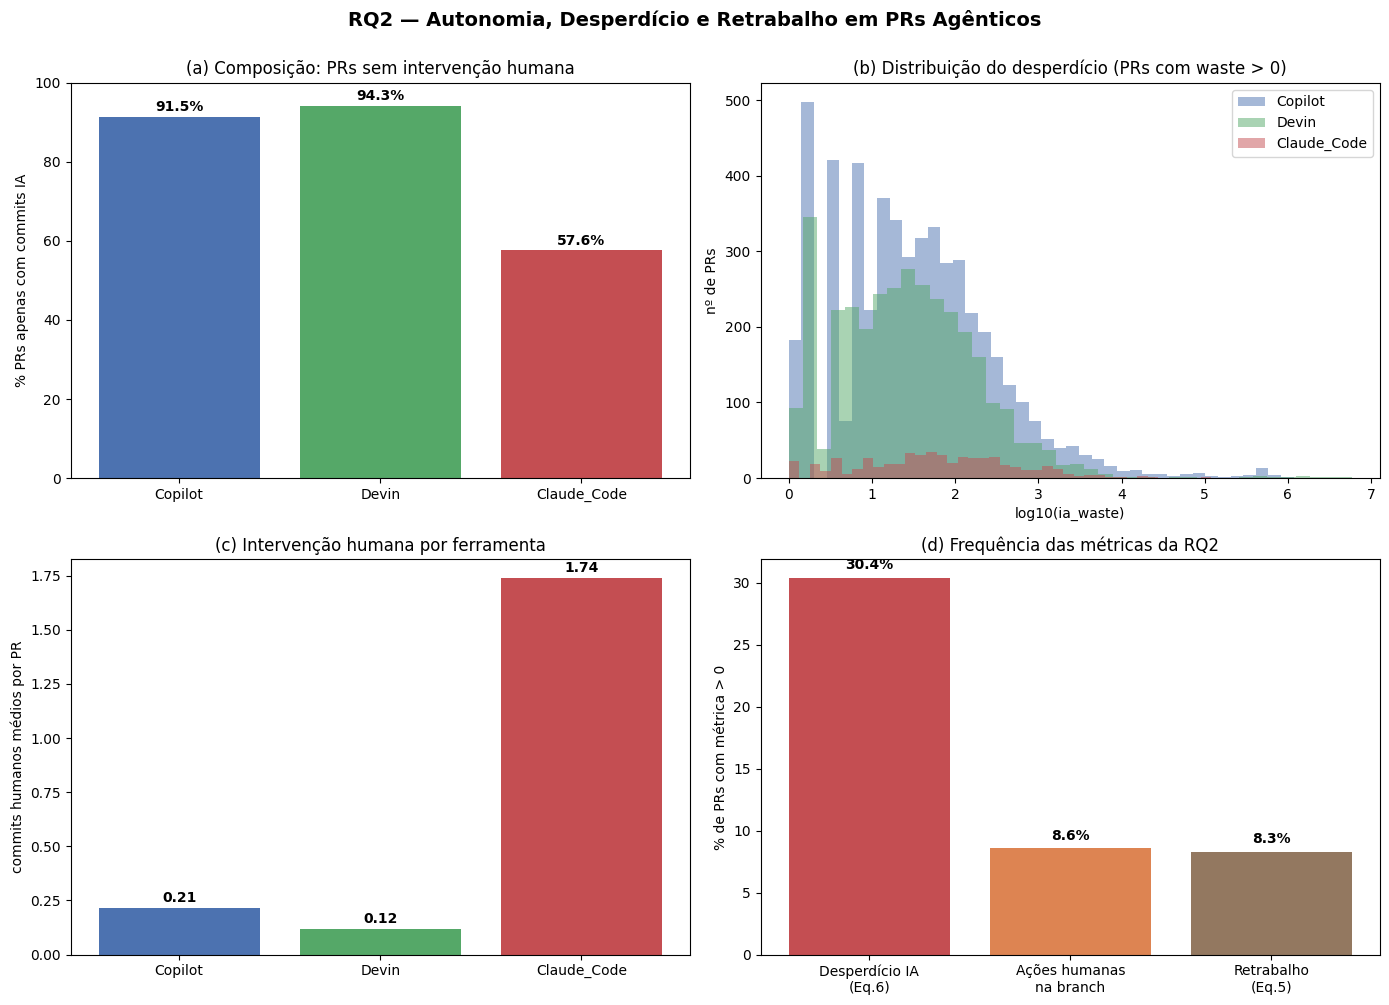

Figura salva: rq2_resultados.png / .pdf


In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
COR = {"Copilot": "#4C72B0", "Devin": "#55A868", "Claude_Code": "#C44E52"}

# (a) % só IA por ferramenta
ax = axes[0, 0]
so_ia_ag = [((valid[valid.agent==ag].number_commits_humano==0) &
             (valid[valid.agent==ag].number_commits_bot==0)).mean()*100 for ag in FERRAMENTAS]
ax.bar(FERRAMENTAS, so_ia_ag, color=[COR[a] for a in FERRAMENTAS])
ax.set_ylabel("% PRs apenas com commits IA"); ax.set_ylim(0, 100)
ax.set_title("(a) Composição: PRs sem intervenção humana")
for i, v in enumerate(so_ia_ag): ax.text(i, v+1.5, f"{v:.1f}%", ha="center", fontweight="bold")

# (b) Distribuição de ia_waste (>0, log) por ferramenta
ax = axes[0, 1]
for ag in FERRAMENTAS:
    pos = valid[(valid.agent==ag) & (valid.ia_waste>0)].ia_waste
    ax.hist(np.log10(pos), bins=40, alpha=0.5, label=ag, color=COR[ag])
ax.set_xlabel("log10(ia_waste)"); ax.set_ylabel("nº de PRs")
ax.set_title("(b) Distribuição do desperdício (PRs com waste > 0)")
ax.legend()

# (c) commits humanos médios por ferramenta
ax = axes[1, 0]
ch = [valid[valid.agent==ag].number_commits_humano.mean() for ag in FERRAMENTAS]
ax.bar(FERRAMENTAS, ch, color=[COR[a] for a in FERRAMENTAS])
ax.set_ylabel("commits humanos médios por PR")
ax.set_title("(c) Intervenção humana por ferramenta")
for i, v in enumerate(ch): ax.text(i, v+0.03, f"{v:.2f}", ha="center", fontweight="bold")

# (d) presença das métricas (% PRs > 0)
ax = axes[1, 1]
mets = ["ia_waste", "spr_humano_actions", "human_rework"]
labels = ["Desperdício IA\n(Eq.6)", "Ações humanas\nna branch", "Retrabalho\n(Eq.5)"]
vals = [(valid[m] > 0).mean()*100 for m in mets]
ax.bar(labels, vals, color=["#C44E52", "#DD8452", "#937860"])
ax.set_ylabel("% de PRs com métrica > 0")
ax.set_title("(d) Frequência das métricas da RQ2")
for i, v in enumerate(vals): ax.text(i, v+0.7, f"{v:.1f}%", ha="center", fontweight="bold")

plt.suptitle("RQ2 — Autonomia, Desperdício e Retrabalho em PRs Agênticos",
             fontsize=14, fontweight="bold", y=1.00)
plt.tight_layout()
plt.savefig("rq2_resultados.png", dpi=200, bbox_inches="tight")
plt.savefig("rq2_resultados.pdf", bbox_inches="tight")
plt.show()
print("Figura salva: rq2_resultados.png / .pdf")

---
### Notas de reprodutibilidade — RQ2

- **Corpus:** 29.923 PRs agênticos válidos (merge real de 2 pais) em 7.859 repositórios,
  a partir do **AIDev completo** (não o AIDev-pop da RQ1).
- **Exclusões:** 11.409 squash/ff (25,2%) + 2.494 merge interno (5,5%) + 1.383 outros erros (3,1%).
- **Composição:** 91,5% dos PRs Copilot são exclusivamente da IA (sem humano e sem bot);
  Devin 94,3%; Claude Code 57,6%.
- **Desperdício de IA (Eq. 6):** presente em 30,4% dos PRs; mediana robusta (>0) de 26 ações.
- **Retrabalho humano (Eq. 5, definição atualizada):** $|S_{\text{pr\_Humano}} \cap S_{\text{merge}}|$
  presente em 8,29% dos PRs (2.480 casos) — quase a totalidade dos PRs com ações humanas na
  branch (8,56%). A definição anterior ($\cap S_{\text{main}}$) era estruturalmente rara
  (0,25%) e foi substituída por refletir melhor o sentido de "contribuição humana absorvida
  no merge".
- **Sobreposição IA + Humano:** 3,14% dos PRs (941 casos) têm ações que aparecem em commits
  de IA e humano simultaneamente, captadas pela coluna `overlap_ia_humano`.
- **Ferramentas:** Claude Code é marcadamente mais colaborativo (57,6% só-IA vs >91% das demais);
  diferenças significativas no desperdício (Kruskal-Wallis $H = 92{,}15$, $p < 0{,}001$,
  Mann-Whitney com Holm $p < 0{,}001$ em todos os pares), embora com tamanho de efeito pequeno
  ($\varepsilon^2 \approx 0{,}003$). A correção de Holm é aplicada legitimamente: os três
  testes par-a-par comparam grupos distintos, configurando uma família de comparações
  independentes (situação diferente da análise de sensibilidade ao $k$ na RQ1).
- **Aviso:** todas as métricas de ações usam medianas; médias são distorcidas por geração
  massiva de código em repositórios de teste/demo.